In [1]:
!python3 complaint_borough.py \
-i 311_2024_zip.csv \
-s 2024-01-01 \
-e 2024-02-29 \
-o jan_feb.csv

In [2]:
import csv
from collections import Counter

totals = Counter()

with open("jan_feb.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for row in reader:
        totals[row["complaint type"]] += int(row["count"])

totals.most_common(10)

[('HEAT/HOT WATER', 81631),
 ('Illegal Parking', 79916),
 ('Noise - Residential', 43601),
 ('Blocked Driveway', 28608),
 ('UNSANITARY CONDITION', 19206),
 ('PLUMBING', 12057),
 ('PAINT/PLASTER', 11725),
 ('Abandoned Vehicle', 11452),
 ('Street Condition', 10741),
 ('WATER LEAK', 9177)]

In [3]:
import matplotlib.pyplot as plt

complaint = "HEAT/HOT WATER"

borough_counts = {}

with open("jan_feb.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["complaint type"] == complaint:
            borough_counts[row["borough"]] = int(row["count"])

borough_counts

{'BRONX': 30139,
 'BROOKLYN': 20915,
 'MANHATTAN': 17604,
 'QUEENS': 12107,
 'STATEN ISLAND': 866}

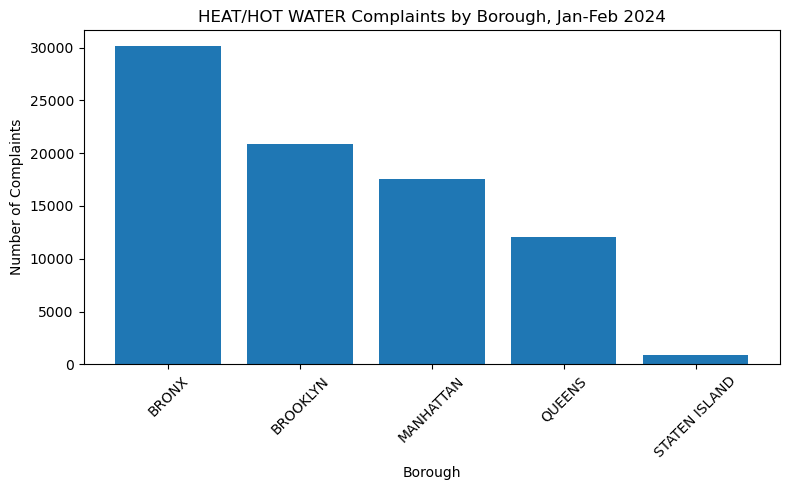

In [4]:
boroughs = list(borough_counts.keys())
counts = list(borough_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(boroughs, counts)

plt.title("HEAT/HOT WATER Complaints by Borough, Jan-Feb 2024")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [5]:
!python3 complaint_borough.py \
-i 311_2024_zip.csv \
-s 2024-06-01 \
-e 2024-07-31 \
-o june_july.csv

In [6]:
june_july_counts = {}

with open("june_july.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["complaint type"] == complaint:
            june_july_counts[row["borough"]] = int(row["count"])

june_july_counts

{'BRONX': 2227,
 'BROOKLYN': 1929,
 'MANHATTAN': 1777,
 'QUEENS': 835,
 'STATEN ISLAND': 121}

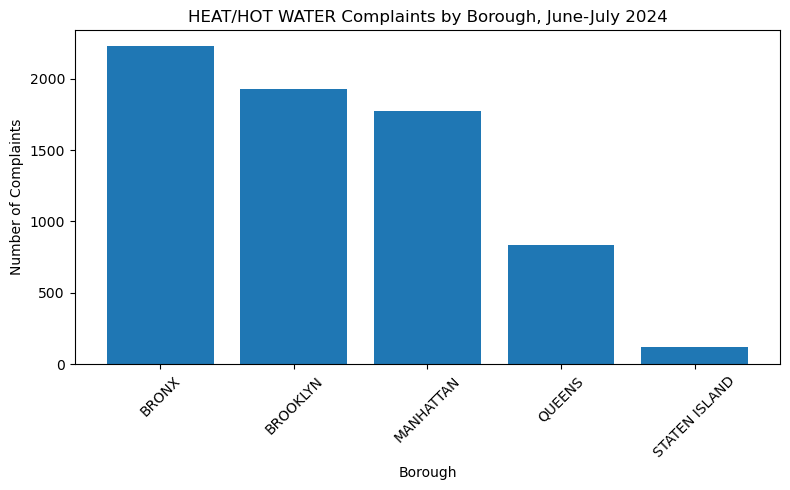

In [7]:
boroughs_jj = list(june_july_counts.keys())
counts_jj = list(june_july_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(boroughs_jj, counts_jj)

plt.title("HEAT/HOT WATER Complaints by Borough, June-July 2024")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [8]:
jan_feb_total = sum(borough_counts.values())
june_july_total = sum(june_july_counts.values())

decrease = jan_feb_total - june_july_total
percent_decrease = decrease / jan_feb_total * 100

jan_feb_total, june_july_total, decrease, percent_decrease

(81631, 6889, 74742, 91.56080410628316)